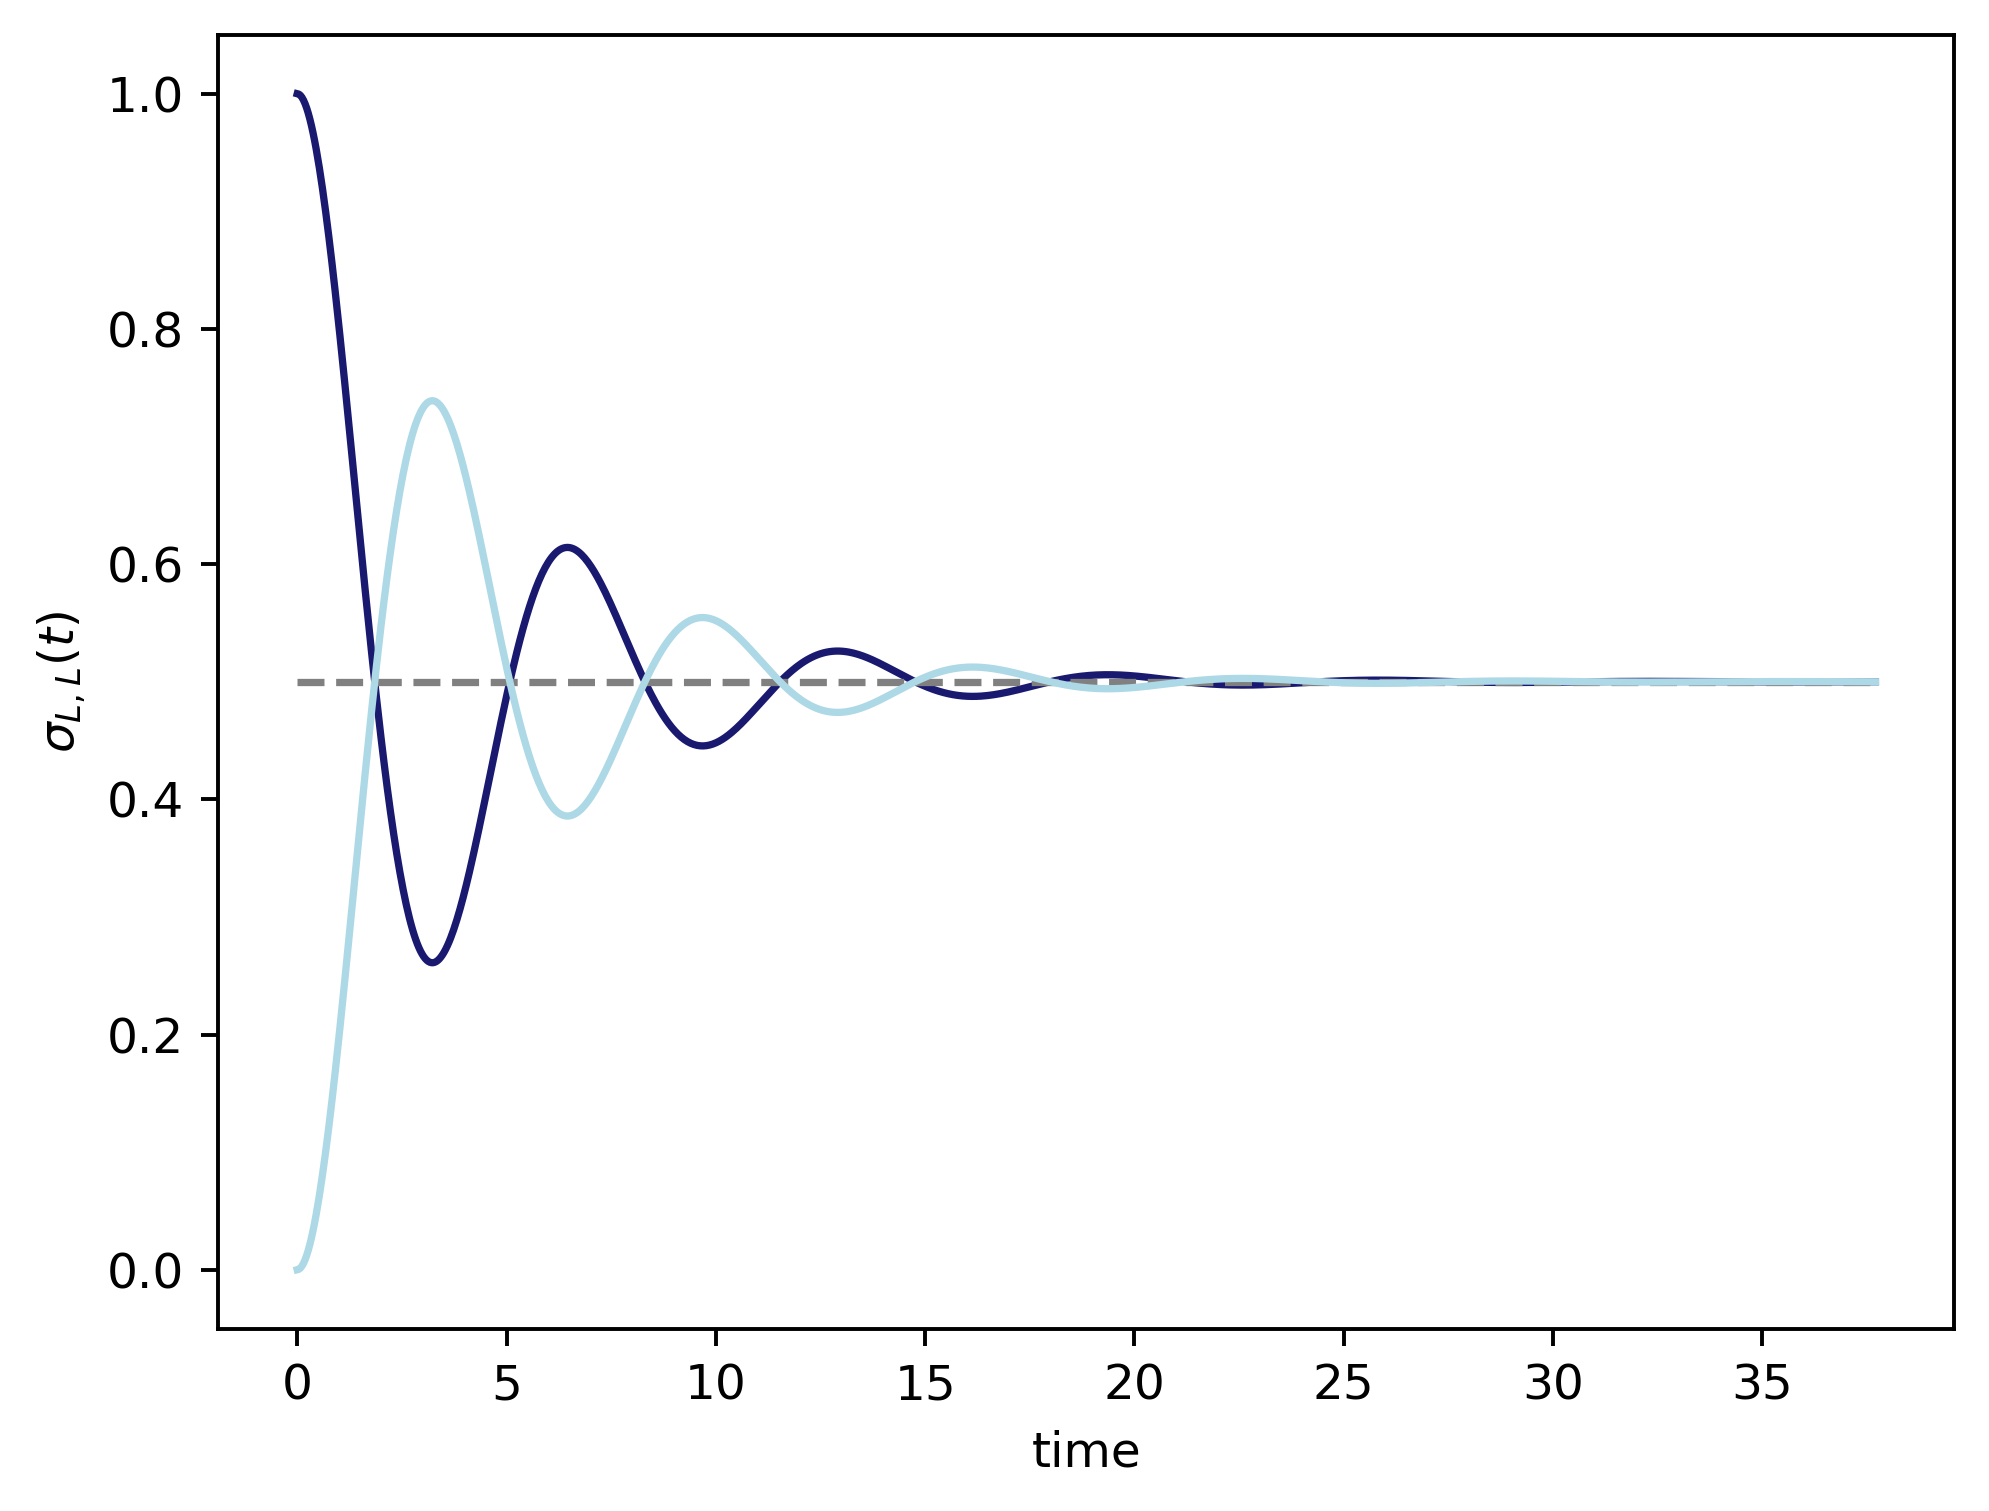

In [6]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt
from scipy.linalg import expm
plt.rcParams['figure.dpi']=350

#parameters-input in L,R order
Delta=1
alpha_list=np.array([0.1,0.05])
wc_list=np.array([20,20])
beta_list=np.array([0.5,0.5])


def J(w,alpha,w_c): #define J(w) with dependancy on alpha
    return 2*alpha*w*np.exp(-w/w_c)

def eta(w,beta): #define eta(w) with dependancy on beta
    return 1/(np.exp(beta*w)-1)

#empty lists to store corresponding transition rates for each of the baths
K_12=[] #will contain K_12_L and K_12_R
K_21=[]
s=[]  #will contain averages of K values
for i in range(len(alpha_list)):
    k12=(1/4)*(np.pi/2)*J(Delta,alpha_list[i],wc_list[i])*eta(Delta,beta_list[i]) 
    k21=(1/4)*(np.pi/2)*J(Delta,alpha_list[i],wc_list[i])*(eta(Delta,beta_list[i])+1)
    K_12.append(k12)
    K_21.append(k21)

for j in range(len(alpha_list)):
    s.append(0.5*(K_12[j]+K_21[j]))

#define c.o.b. matrix for vectorised RDM (sigma in LR to sigma in 12)
U=(1/np.sqrt(2))*np.array([[1,1],[-1,1]])
R=np.kron(np.conj(U),U) 

#build super operator for sigma in 12 basis
#start with unitary part
super_op=np.array([[0,0,0,0],
                 [0,-Delta*1j,0,0],
                 [0,0,Delta*1j,0],
                 [0,0,0,0]])
#add R and L dissipators
for j in range(len(alpha_list)):
    super_op+=np.array([[-K_12[j],0,0,K_21[j]],
            [0,-s[j], s[j],0],
            [0,s[j],-s[j],0],
            [K_12[j],0,0,-K_21[j]]])

#define initial condition in LR basis
sigma0=zeros(2,2)
sigma0[0,0]=1 #|L> is occupied
sigma0_vec=np.array(sigma0.T.reshape(4, 1),dtype=complex) #vectorised DM in LR basis, column stack

times=np.linspace(0,12*np.pi,1000) #simulation time array until 6*2pi/Delta 

P_LL=[] #list to store probability sigma_LL
P_RR=[]
for t in times:
    sigma=expm(R@super_op@np.linalg.inv(R)*t)@sigma0_vec
    P_LL.append(sigma[0,0].real) #take real part due to approximations 
    P_RR.append(sigma[3,0].real)
P_LL=np.array(P_LL)
P_RR=np.array(P_RR)
#plot
plt.plot(times,P_LL,color='midnightblue')
plt.plot(times,np.average(P_LL[900:])*np.ones_like(P_LL),color='grey',ls='--')
plt.plot(times,P_RR,color='lightblue')
plt.xlabel('time')
plt.ylabel('$\\sigma_{{L,L}}(t)$')
#plt.title(f'$\\alpha={alpha},\\beta={beta}$')
plt.show()
